Loading PLINK results...
Loading GERMLINE results...
Detected columns: 15
Merging datasets...
PLINK pairs example:
0    (NA19020, NA19028)
1    (NA19020, NA19035)
2    (NA19020, NA19036)
3    (NA19020, NA19038)
4    (NA19020, NA19041)
Name: pair_id, dtype: object
GERMLINE pairs example:
0    NA19020_NA19020
Name: pair_id, dtype: object
Matched pairs = 0

===== Summary Statistics =====
Not enough data points for correlation analysis.
Number of matched pairs = 0


/var/folders/_6/jzzgxq8d5671gg7bq2kyj2nw0000gn/T/ipykernel_63799/1981798506.py:74: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["IID1"] = df["IID1"].astype(str)
/var/folders/_6/jzzgxq8d5671gg7bq2kyj2nw0000gn/T/ipykernel_63799/1981798506.py:75: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["IID2"] = df["IID2"].astype(str)
/var/folders/_6/jzzgxq8d5671gg7bq2kyj2nw0000gn/T/ipykernel_63799/1981798506.py:78: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try usi

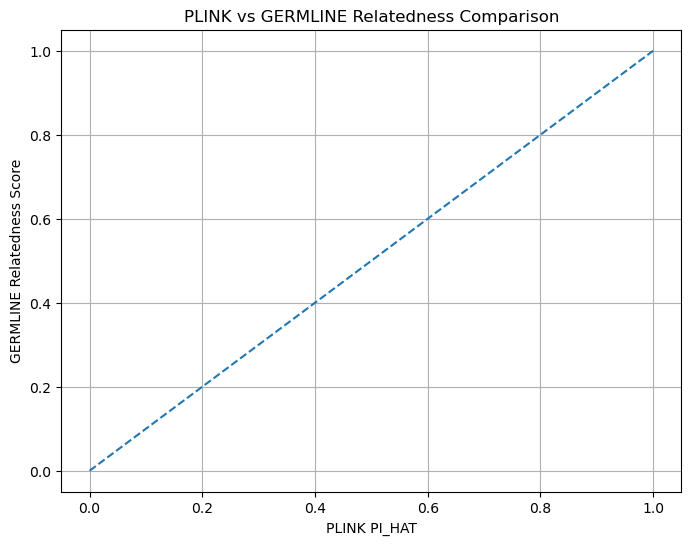

In [9]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# Approximate total haploid genome length (cM)
GENOME_LENGTH_CM = 3600

# File paths
PLINK_FILE = "./results/plink_results/full_plink.genome"
GERMLINE_FILE = "./results/germline_results/full_germline_output.match"

# Load plink and germline results
def load_plink_results(filepath):
    """
    Load PLINK IBD estimation results.

    Expected columns include:
    IID1, IID2, PI_HAT
    """

    df = pd.read_csv(filepath, delim_whitespace=True)

    # Standardize pair ordering
    df["pair_id"] = df.apply(
        lambda row: tuple(sorted([row["IID1"], row["IID2"]])),
        axis=1
    )

    return df[["pair_id", "IID1", "IID2", "PI_HAT"]]

def load_germline_results(filepath):

    if not os.path.exists(filepath) or os.path.getsize(filepath) == 0:
        print("GERMLINE output empty")
        return pd.DataFrame()

    df = pd.read_csv(filepath, sep=r"\s+", header=None, engine="python")

    print("Detected columns:", df.shape[1])

    # IDs
    iid1 = df[0]
    iid2 = df[1]

    # length column (second to last numeric column usually)
    length = pd.to_numeric(df.iloc[:, -4], errors="coerce")

    out = pd.DataFrame({
        "IID1": iid1,
        "IID2": iid2,
        "length": length
    })

    return out

# Normalize GERMLINE Relatedness Score
def compute_germline_relatedness(df):

    if df.empty:
        return pd.DataFrame(columns=["pair_id", "GERMLINE_score"])

    # Split IDs safely
    ids = df["IID1"].str.split("_", expand=True)

    df["IID1"] = ids[0]
    df["IID2"] = ids[1]

    # Remove missing IDs (important!)
    df = df.dropna(subset=["IID1", "IID2"])

    # Convert to string explicitly
    df["IID1"] = df["IID1"].astype(str)
    df["IID2"] = df["IID2"].astype(str)

    # Create standardized pair ID (avoid None sorting error)
    df["pair_id"] = df.apply(
        lambda r: "_".join(sorted([r["IID1"], r["IID2"]])),
        axis=1
    )

    # Aggregate IBD lengths
    pair_lengths = df.groupby("pair_id")["length"].sum().reset_index()

    genome_length_mb = 3000
    pair_lengths["GERMLINE_score"] = pair_lengths["length"] / genome_length_mb

    return pair_lengths[["pair_id", "GERMLINE_score"]]


# Merge PLINK and GERMLINE Results
def merge_results(plink_df, germline_df):
    print("PLINK pairs example:")
    print(plink_df["pair_id"].head())

    print("GERMLINE pairs example:")
    print(germline_df["pair_id"].head())
    merged = pd.merge(
        plink_df,
        germline_df,
        on="pair_id",
        how="inner"
    )

    return merged

# Analysis Metrics
def analyze_results(merged_df):

    print("\n===== Summary Statistics =====")

    if merged_df.empty or len(merged_df) < 2:
        print("Not enough data points for correlation analysis.")
        print(f"Number of matched pairs = {len(merged_df)}")
        return

    print("\nPLINK PI_HAT:")
    print(merged_df["PI_HAT"].describe())

    print("\nGERMLINE Score:")
    print(merged_df["GERMLINE_score"].describe())

    # Correlation
    try:
        corr, pval = pearsonr(
            merged_df["PI_HAT"],
            merged_df["GERMLINE_score"]
        )

        print("\n===== Correlation Analysis =====")
        print(f"Pearson correlation = {corr:.4f}")
        print(f"p-value = {pval:.4e}")

    except Exception:
        print("Correlation could not be computed (insufficient data).")


# Plot Comparisons
def plot_scatter(merged_df):
    plt.figure(figsize=(8, 6))

    plt.scatter(
        merged_df["PI_HAT"],
        merged_df["GERMLINE_score"],
        alpha=0.6
    )

    # Identity line
    plt.plot([0, 1], [0, 1], linestyle="--")

    plt.xlabel("PLINK PI_HAT")
    plt.ylabel("GERMLINE Relatedness Score")
    plt.title("PLINK vs GERMLINE Relatedness Comparison")

    plt.grid(True)
    plt.show()

def main():
    print("Loading PLINK results...")
    plink_df = load_plink_results(PLINK_FILE)

    print("Loading GERMLINE results...")
    germline_raw = load_germline_results(GERMLINE_FILE)

    germline_df = compute_germline_relatedness(germline_raw)

    print("Merging datasets...")
    merged_df = merge_results(plink_df, germline_df)

    print(f"Matched pairs = {len(merged_df)}")

    analyze_results(merged_df)

    plot_scatter(merged_df)


if __name__ == "__main__":
    main()